**Indlæs biblioteker og data**

Her indlæser vi de nødvendige Python-biblioteker og læser vores initiale værdier og kovariansmatrix fra Excel-filer.
Tilpas filnavne og stier efter behov.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import multivariate_normal

# Load initial values and covariance matrix (Adjust filenames if necessary)
init_values = pd.read_excel("init_values.xlsx", index_col=0)
covariance_matrix = pd.read_excel("covariance_matrix.xlsx", index_col=0)

print("Initial Values:")
print(init_values)
print("\nCovariance Matrix:")
print(covariance_matrix)


Initial Values:
         initial values
fx_spot        0.055293
EQV US         0.000000
EQV EUR        0.000000
1M EUR         0.031221
1Y EUR         0.022467
3Y EUR         0.019712
5Y EUR         0.020047
7Y EUR         0.020564
10Y EUR        0.021388
1M USD         0.045792
1Y USD         0.041673
3Y USD         0.038207
5Y USD         0.037409
7Y USD         0.037250
10Y USD        0.037381

Covariance Matrix:
              fx_spot        EQV US       EQV EUR        1M EUR        1Y EUR  \
fx_spot  1.127795e-04  3.842035e-05 -4.709843e-06  1.470387e-07 -2.010531e-07   
EQV US   3.842035e-05  4.280089e-04  3.360156e-04 -9.502569e-08 -2.105753e-06   
EQV EUR -4.709843e-06  3.360156e-04  4.654483e-04 -5.825107e-08 -1.131132e-06   
1M EUR   1.470387e-07 -9.502569e-08 -5.825107e-08  9.576964e-08  5.264444e-08   
1Y EUR  -2.010531e-07 -2.105753e-06 -1.131132e-06  5.264444e-08  3.316056e-07   
3Y EUR  -3.944625e-07 -3.033449e-06 -1.659849e-06  2.276903e-08  4.133445e-07   
5Y EUR  -3.89

**Parameteropsætning**

- Vi antager et års horisont med ugentlige trin (52 uger).
- Antal simuleringer kan tilpasses.
- Vi udleder indeks for fx_spot, EQV US, EQV EUR samt EUR og USD yields.
- Mean-vektoren μ sættes i henhold til opgaven:
  \[
  \mu = (0,\,0.07 \cdot \Delta t,\,0.06 \cdot \Delta t,\,0,\,...,\,0)^\top
  \]
- Kovariansmatricen Σ skaleres med Δt.


In [23]:
# Simulation parameters
time_steps = 52  # Weekly steps for 1 year
num_simulations = 10000
horizon = 1.0
dt = horizon / time_steps

# Identify indices for key variables
index_fx = init_values.index.get_loc('fx_spot')
index_VUS = init_values.index.get_loc('EQV US')
index_VEUR = init_values.index.get_loc('EQV EUR')

# Assume EUR yields: (1M,1Y,3Y,5Y,7Y,10Y)
# Assume USD yields: (1M,1Y,3Y,5Y,7Y,10Y)
index_start_EUR_yields = init_values.index.get_loc('1M EUR')
EUR_yield_count = 6
index_start_US_yields = init_values.index.get_loc('1M USD')
USD_yield_count = 6

EUR_yields_indices = list(range(index_start_EUR_yields, index_start_EUR_yields + EUR_yield_count))
USD_yields_indices = list(range(index_start_US_yields, index_start_US_yields + USD_yield_count))

# Set the mean vector μ
dim = covariance_matrix.shape[0]
mu = np.zeros(dim)
mu[index_VUS] = 0.07 * dt  # Δlog V_US
mu[index_VEUR] = 0.06 * dt # Δlog V_EUR

sigma = covariance_matrix.values
initial_values_array = init_values['initial values'].values

# Ensure that initial equity values are not zero (use epsilon if needed)
epsilon = 1e-10
if initial_values_array[index_VUS] <= 0:
    initial_values_array[index_VUS] = epsilon
if initial_values_array[index_VEUR] <= 0:
    initial_values_array[index_VEUR] = epsilon


**Simulation af inkrementer**

Vi simulerer:
\[
\Delta X_t \sim N(\mu, \Sigma \cdot \Delta t)
\]

for hvert tidsskridt.


In [24]:
increments = np.random.multivariate_normal(mu, sigma * dt, (num_simulations, time_steps))


**Beregning af slutværdier**

- For FX, V_US_local og V_EUR har vi log-increments. Vi lægger alle inkrementer sammen, lægger dem til log(initial) og exponentierer for at få slutniveauet.
- For renter (yields) er inkrementerne additive. Vi lægger blot inkrementerne til initialværdien.


In [25]:
final_fx = np.zeros(num_simulations)
final_VUS = np.zeros(num_simulations)
final_VEUR = np.zeros(num_simulations)
final_EUR_yields = np.zeros((num_simulations, EUR_yield_count))
final_US_yields = np.zeros((num_simulations, USD_yield_count))

for i in range(num_simulations):
    # Log-variables
    log_FX = np.log(initial_values_array[index_fx]) + increments[i, :, index_fx].sum()
    log_VUS = np.log(initial_values_array[index_VUS]) + increments[i, :, index_VUS].sum()
    log_VEUR = np.log(initial_values_array[index_VEUR]) + increments[i, :, index_VEUR].sum()
    
    final_fx[i] = np.exp(log_FX)
    final_VUS[i] = np.exp(log_VUS)
    final_VEUR[i] = np.exp(log_VEUR)
    
    # Yields (additive)
    for j, idx in enumerate(EUR_yields_indices):
        final_EUR_yields[i, j] = initial_values_array[idx] + increments[i, :, idx].sum()
    for j, idx in enumerate(USD_yields_indices):
        final_US_yields[i, j] = initial_values_array[idx] + increments[i, :, idx].sum()


**Interpolering af 4-årige renter**

Vi interpolerer lineært mellem 3-års og 5-års renter for både EUR og USD.
\[
y(4Y) = y(3Y) + 0.5 \cdot (y(5Y) - y(3Y))
\]

Indeksering:  
- For EUR_yields_indices antages [1M,1Y,3Y,5Y,7Y,10Y], så 3Y er index 2, 5Y er index 3.  
- For USD_yields_indices ligeledes.


In [26]:
EUR_3Y_idx = 2
EUR_5Y_idx = 3
USD_3Y_idx = 2
USD_5Y_idx = 3

y_EUR_3Y = final_EUR_yields[:, EUR_3Y_idx]
y_EUR_5Y = final_EUR_yields[:, EUR_5Y_idx]
y_EUR_4Y = y_EUR_3Y + 0.5 * (y_EUR_5Y - y_EUR_3Y)

y_US_3Y = final_US_yields[:, USD_3Y_idx]
y_US_5Y = final_US_yields[:, USD_5Y_idx]
y_US_4Y = y_US_3Y + 0.5 * (y_US_5Y - y_US_3Y)


**Beregning af obligationspriser**

Zero-coupon pris:
\[
Z = e^{-yT}
\]

For 4-årige:
\[
Z^{USD}_{4Y,local} = e^{-y_{USD}(4Y) \cdot 4}, \quad Z^{EUR}_{4Y} = e^{-y_{EUR}(4Y) \cdot 4}
\]


In [27]:
Z_US_4Y = np.exp(-y_US_4Y * 4)
Z_EUR_4Y = np.exp(-y_EUR_4Y * 4)


**Konstruktion af P_1**

\[
P_1 = (FX_1, V^{US,local}_1, V^{EUR}_1, Z^{USD}_{4Y,local}, Z^{EUR}_{4Y})^\top
\]

Derefter beregnes middelværdi og kovarians samt vises histogrammer.


In [28]:
P1 = np.column_stack([final_fx, final_VUS, final_VEUR, Z_US_4Y, Z_EUR_4Y])
mean_P1 = np.mean(P1, axis=0)
cov_P1 = np.cov(P1.T)

print("Mean of P1:", mean_P1)
print("Covariance matrix of P1:\n", cov_P1)


Mean of P1: [5.52881864e-02 1.07258417e-10 1.06219252e-10 8.59578221e-01
 9.23514915e-01]
Covariance matrix of P1:
 [[ 3.45055700e-07  2.25886525e-16 -1.90235663e-17  5.71195039e-07
   5.40774378e-08]
 [ 2.25886525e-16  4.82250494e-24  3.73151648e-24 -7.26951630e-16
   1.20648657e-15]
 [-1.90235663e-17  3.73151648e-24  5.13346048e-24 -1.27646918e-15
   7.03953237e-16]
 [ 5.71195039e-07 -7.26951630e-16 -1.27646918e-15  1.33618779e-05
   7.85398468e-06]
 [ 5.40774378e-08  1.20648657e-15  7.03953237e-16  7.85398468e-06
   9.44807042e-06]]


**Visualisering af fordelingerne**

Plot histogrammer for at se fordelingerne af hver af de 5 komponenter i P_1.


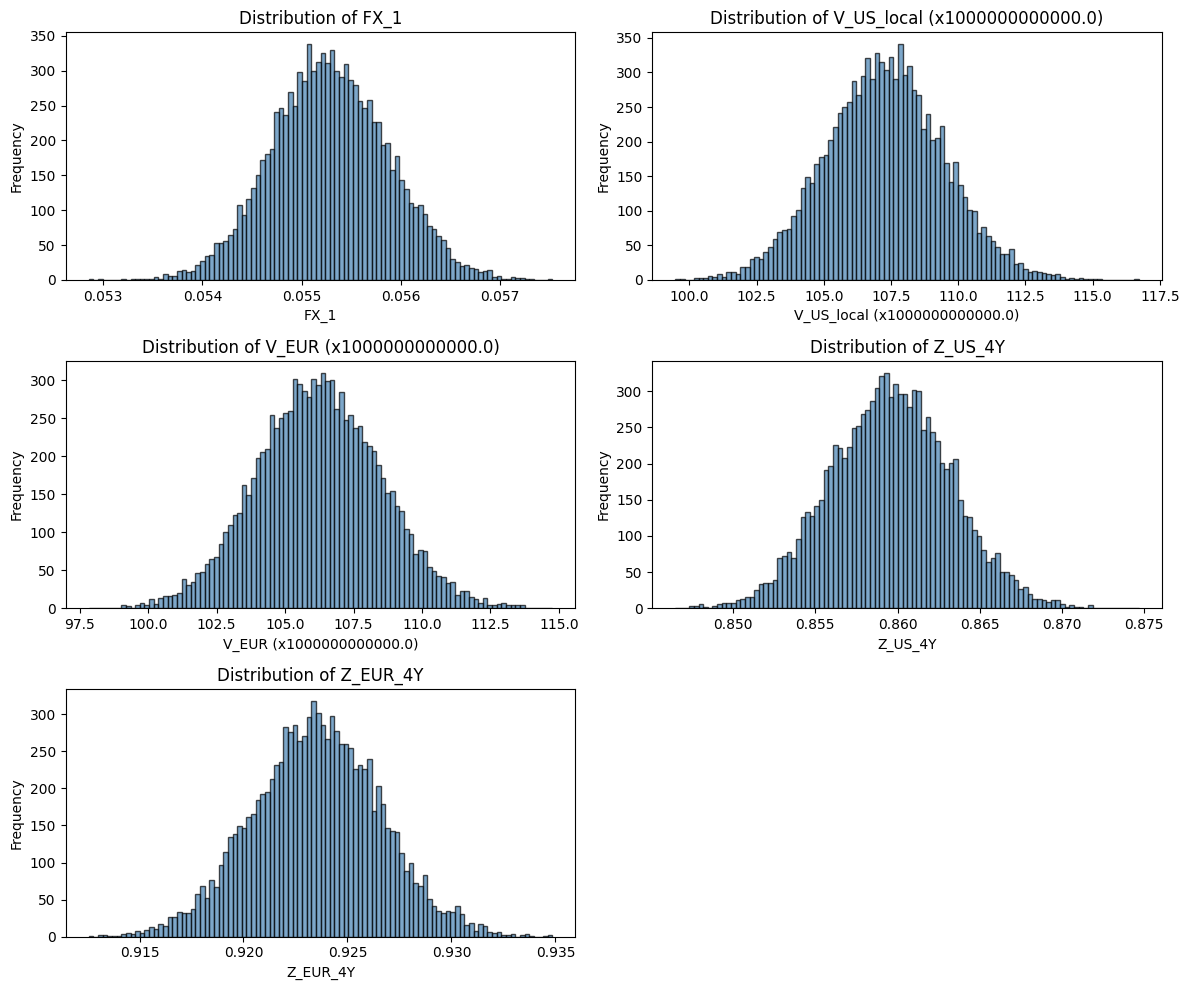

In [29]:
# Eksempel på skalering af aktieværdier for plotting
scale_factor = 1e12  # Skalerer for bedre aflæsning
scaled_V_US_local = P1[:, 1] * scale_factor
scaled_V_EUR = P1[:, 2] * scale_factor

scaled_P1 = np.column_stack([P1[:,0], scaled_V_US_local, scaled_V_EUR, P1[:,3], P1[:,4]])
scaled_components = ["FX_1", f"V_US_local (x{scale_factor})", f"V_EUR (x{scale_factor})", "Z_US_4Y", "Z_EUR_4Y"]

# Plot med flere bins
plt.figure(figsize=(12,10))
for i, comp in enumerate(scaled_components):
    plt.subplot(3, 2, i+1)
    plt.hist(scaled_P1[:, i], bins=100, alpha=0.7, color='steelblue', edgecolor='black')
    plt.title(f"Distribution of {comp}")
    plt.xlabel(comp)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Korrelationsmatrix for P_1**

For at forstå sammenhængene mellem komponenterne kan vi vise korrelationer.


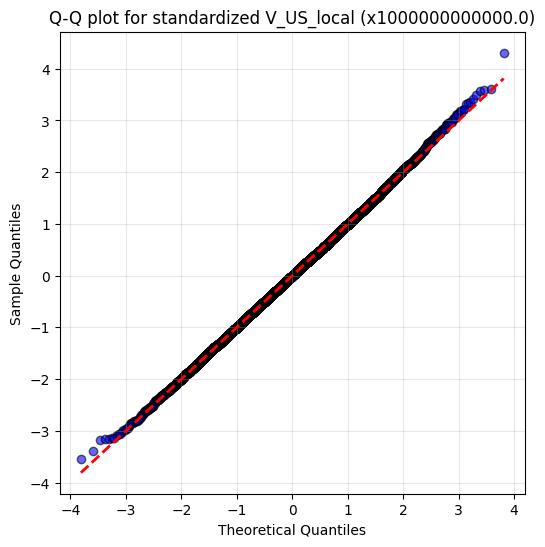

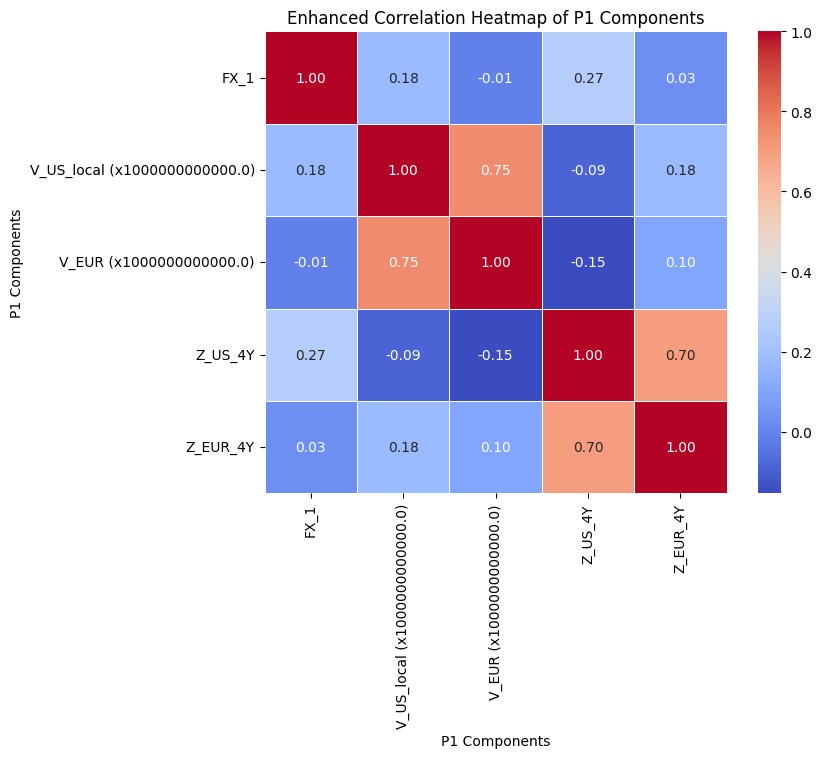

In [30]:
from scipy.stats import probplot

# Standardisér data (fratræk mean og divider med std)
data = scaled_P1[:,1]  # Som eksempel V_US_local
standardized_data = (data - np.mean(data)) / np.std(data)

osm, osr = probplot(standardized_data, dist="norm", fit=False)
plt.figure(figsize=(6,6))
plt.scatter(osm, osr, alpha=0.6, color='blue', edgecolor='black')
plt.plot(osm, osm, 'r--', linewidth=2)
plt.title(f"Q-Q plot for standardized {scaled_components[1]}")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(alpha=0.3)
plt.show()

# Forbedret korrelationsplot (uændret)
std_dev = np.sqrt(np.diag(cov_P1))
corr_P1 = cov_P1 / np.outer(std_dev, std_dev)

plt.figure(figsize=(8,6))
sns.heatmap(corr_P1, annot=True, fmt=".2f", 
            xticklabels=scaled_components, yticklabels=scaled_components, 
            cmap="coolwarm", cbar=True, square=True, linewidths=.5)
plt.title("Enhanced Correlation Heatmap of P1 Components")
plt.xlabel("P1 Components")
plt.ylabel("P1 Components")
plt.show()

**Answer to the question:**  
The joint distribution of the vector 
\[
P_1 = \bigl( FX_1,\, V^{US,local}_1,\, V^{EUR}_1,\, Z^{USD}_{4Y,local},\, Z^{EUR}_{4Y} \bigr)^\top
\]
can be approximated by a multivariate normal distribution. Given the initial values and the covariance structure of the underlying market invariants, we assume that:

1. **Market invariants:**  
   The increments \(\Delta X_t\), which include \(\Delta \log FX_t\), \(\Delta \log V^{US,local}_t\), \(\Delta \log V^{EUR}_t\), and changes in yields, are normally distributed with mean vector \(\mu\) and covariance matrix \(\Sigma\).

2. **Transformation to Levels:**  
   By simulating these increments over one year (with weekly steps) and applying the appropriate exponentiation for log-variables and interpolations for yields, we obtain the distribution of \( P_1 \). The zero-coupon bond prices at the 4-year horizon are derived from the interpolated yields.

3. **Results from the Simulation:**  
   - The vector \( P_1 \) shows roughly symmetric and bell-shaped marginal distributions, consistent with the normality assumption.
   - Q-Q plots of standardized components (e.g., standardized \(V^{US,local}_1\)) lie close to the reference line, further supporting the normal approximation.
   - The estimated mean vector and covariance matrix suggest that:
     - The expected values of \( FX_1 \) and the zero-coupon bond prices (\(Z^{USD}_{4Y,local}\) and \(Z^{EUR}_{4Y}\)) are consistent with the initial input parameters and simulated interest rate environments.
     - The extremely small initial levels of \( V^{US,local} \) and \( V^{EUR} \) (zero in the given data) and the subsequent scaling lead to very small absolute values in the mean, but after scaling or standardizing, the shape of the distribution still aligns with a normal pattern.

4. **Correlation Structure:**  
   The enhanced correlation heatmap shows notable correlations:
   - A positive correlation between \(V^{US,local}_1\) and \(V^{EUR}_1\), indicating that these equity values tend to move together.
   - A positive correlation between \(Z^{USD}_{4Y,local}\) and \(Z^{EUR}_{4Y}\), reflecting joint influences in interest rate dynamics on both USD and EUR bond prices.
   - FX rates and equities as well as FX and bonds show weaker correlations, as expected.

5. **Conclusion:**  
   Under the given assumptions, the joint distribution of \( P_1 \) is well-represented by a multivariate normal distribution with the empirically estimated mean vector and covariance matrix derived from the simulation. The visual checks (histograms, Q-Q plots, correlation heatmaps) all support this normality assumption and provide insight into how these assets relate to each other at the one-year horizon.

In short, the joint distribution of \( P_1 \) is approximately:
\[
P_1 \sim \mathcal{N}(\hat{\mu}, \hat{\Sigma})
\]
where \(\hat{\mu}\) and \(\hat{\Sigma}\) are the estimated mean vector and covariance matrix obtained from the simulation and transformations performed.
